In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv(r"C:\Users\KIIT\Downloads\shopping_table.csv")

In [5]:
df.head()

,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item_Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase_Amount_USD       3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review_Rating             3900 non-null   float64
 11  Subscription_Status       3900 non-null   object 
 12  Payment_Method            3900 non-null   object 
 13  Shipping_Type             3900 non-null   object 
 14  Discount

In [7]:
df.describe()

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [8]:
df.isnull().sum()

Customer_ID                 0
Age                         0
Gender                      0
Item_Purchased              0
Category                    0
Purchase_Amount_USD         0
Location                    0
Size                        0
Color                       0
Season                      0
Review_Rating               0
Subscription_Status         0
Payment_Method              0
Shipping_Type               0
Discount_Applied            0
Promo_Code_Used             0
Previous_Purchases          0
Preferred_Payment_Method    0
Frequency_of_Purchases      0
dtype: int64

In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 3900
Columns : 19


In [10]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases'],
      dtype='object')

In [11]:
df.groupby("Category")["Purchase_Amount_USD"].mean().sort_values()

Category
Outerwear      57.172840
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Name: Purchase_Amount_USD, dtype: float64

In [12]:
df.groupby("Season")["Purchase_Amount_USD"].mean()

Season
Fall      61.556923
Spring    58.737738
Summer    58.405236
Winter    60.357364
Name: Purchase_Amount_USD, dtype: float64

In [13]:
df.groupby("Gender")["Purchase_Amount_USD"].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase_Amount_USD, dtype: float64

In [14]:
df.groupby("Location")["Purchase_Amount_USD"].sum().sort_values(ascending=False).head(10)

Location
Montana          5784
Illinois         5617
California       5605
Idaho            5587
Nevada           5514
Alabama          5261
New York         5257
North Dakota     5220
West Virginia    5174
Nebraska         5172
Name: Purchase_Amount_USD, dtype: int64

In [15]:
le = LabelEncoder()

df["Gender_Encoded"] = le.fit_transform(df["Gender"])
df["Season_Encoded"] = le.fit_transform(df["Season"])
df["Category_Encoded"] = le.fit_transform(df["Category"])

In [16]:
features = df[
[
'Age',
'Purchase_Amount_USD',
'Previous_Purchases',
'Review_Rating'
]
]

In [17]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [18]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_features)

    wcss.append(kmeans.inertia_)

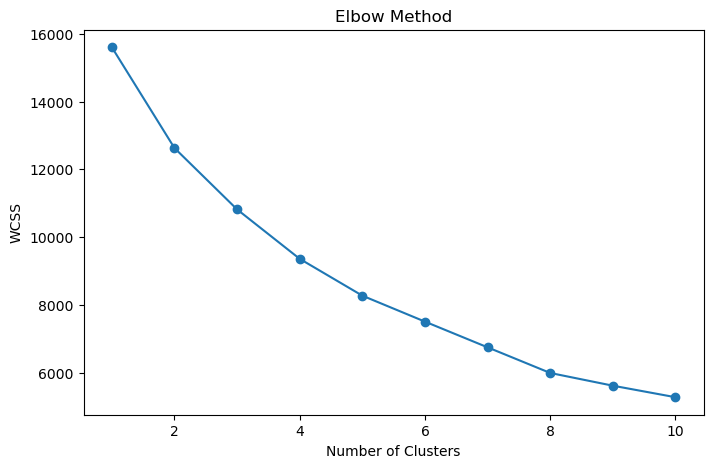

In [19]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [20]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

In [21]:
df["Cluster"].value_counts()

Cluster
0    1438
2    1262
1    1200
Name: count, dtype: int64

In [22]:
df.groupby("Cluster")[
[
'Age',
'Purchase_Amount_USD',
'Previous_Purchases',
'Review_Rating'
]
].mean()

,Age,Purchase_Amount_USD,Previous_Purchases,Review_Rating
Cluster,,,,
0,28.415855,60.301808,21.563978,3.765716
1,53.270833,81.384167,27.874167,3.949167
2,53.153724,38.594295,27.268621,3.542552


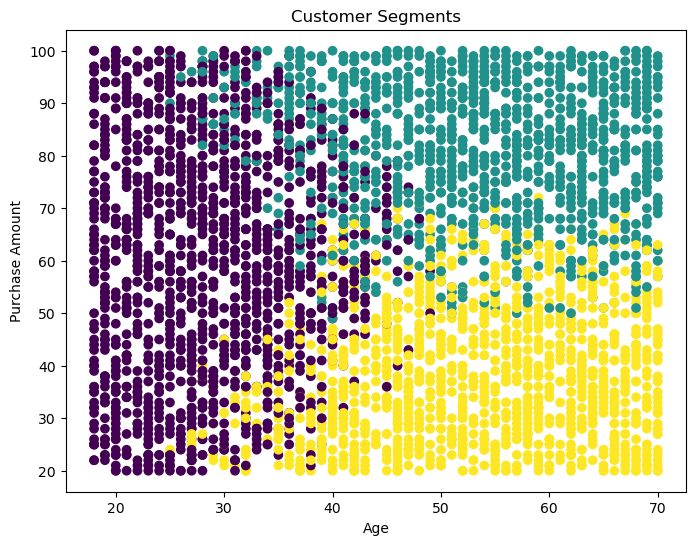

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(
df['Age'],
df['Purchase_Amount_USD'],
c=df['Cluster']
)

plt.xlabel("Age")

plt.ylabel("Purchase Amount")

plt.title("Customer Segments")

plt.show()

In [24]:
df.groupby("Cluster")["Purchase_Amount_USD"].sum()

Cluster
0    86714
1    97661
2    48706
Name: Purchase_Amount_USD, dtype: int64

In [25]:
df.groupby("Cluster")[
[
'Age',
'Purchase_Amount_USD',
'Previous_Purchases',
'Review_Rating'
]
].mean().round(2)

,Age,Purchase_Amount_USD,Previous_Purchases,Review_Rating
Cluster,,,,
0,28.42,60.30,21.56,3.77
1,53.27,81.38,27.87,3.95
2,53.15,38.59,27.27,3.54


In [26]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category',
       'Purchase_Amount_USD', 'Location', 'Size', 'Color', 'Season',
       'Review_Rating', 'Subscription_Status', 'Payment_Method',
       'Shipping_Type', 'Discount_Applied', 'Promo_Code_Used',
       'Previous_Purchases', 'Preferred_Payment_Method',
       'Frequency_of_Purchases', 'Gender_Encoded', 'Season_Encoded',
       'Category_Encoded', 'Cluster'],
      dtype='object')

In [27]:
df.to_csv("Customer_Segmentation_Output.csv", index=False)